# 13 — Organ Enrichment & Gene-Disease Validation

**Question:** Do the PC-derived gene importance rankings for our qualifying tissue × pathology pairs
reflect (a) organ-specific blood biology and (b) known clinical biomarkers?

**Approach:** GSEA prerank against two independent reference gene sets, integrated into a single
per-pair scorecard and a cross-layer flagship gene list.

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import gseapy as gp
from gtex_biomarkers.config import Config

Config.ensure_dirs()
CORAL, STEEL, GRAY = "#C44E52", "#4878A8", "#AAAAAA"
plt.rcParams.update({"figure.dpi": 120, "figure.facecolor": "white"})

# Gene importance rankings
imp = pd.read_csv(Config.TABLES_DIR / "pc_gene_importance_full.csv")
imp["gene_upper"] = imp["gene_name"].str.upper()

# Organ plasma proteins (Oh et al. 2023, Supp. Table 5)
plasma = pd.read_excel(Config.RAW_DIR / "41586_2023_6802_MOESM5_ESM.xlsx", sheet_name="ST5")
PLASMA = {organ: sorted(set(g.split(".")[0].upper() for g in plasma[organ].dropna()))
          for organ in plasma.columns}

# Pair-to-organ mapping.
# Built dynamically: take whatever tissue x category pairs qualified for PC modelling
# (i.e. are present in pc_gene_importance_full.csv) and keep those whose tissue maps
# to an organ column that exists in the plasma protein reference.
TISSUE_TO_ORGAN = {
    "Liver": "Liver",
    "Lung": "Lung",
    "Small Intestine - Terminal Ileum": "Intestine",
    "Colon - Sigmoid": "Intestine", "Colon - Transverse": "Intestine",
    "Stomach": "Intestine",
    "Artery - Tibial": "Artery", "Artery - Aorta": "Artery",
    "Artery - Coronary": "Artery",
    "Heart - Left Ventricle": "Heart", "Heart - Atrial Appendage": "Heart",
    "Muscle - Skeletal": "Muscle",
    "Pancreas": "Pancreas",
    "Kidney - Cortex": "Kidney", "Kidney - Medulla": "Kidney",
    "Brain - Cortex": "Brain", "Brain - Cerebellum": "Brain",
    "Adipose - Subcutaneous": "Adipose",
    "Adipose - Visceral (Omentum)": "Adipose",
}
PAIR_ORGAN = {}
for tissue, cat in imp.groupby(["tissue", "category"]).groups.keys():
    organ = TISSUE_TO_ORGAN.get(tissue)
    if organ and organ in PLASMA:
        PAIR_ORGAN[(tissue, cat)] = organ
PAIRS = list(PAIR_ORGAN.keys())
print(f"\nPair -> organ mapping ({len(PAIRS)} qualifying pairs):")
for p, o in PAIR_ORGAN.items():
    print(f"  {p[0]} | {p[1]} -> {o}")

print("Plasma protein gene set sizes:", {k: len(v) for k,v in PLASMA.items() if k in set(PAIR_ORGAN.values())})



Pair -> organ mapping (4 qualifying pairs):
  Liver | cirrhosis -> Liver
  Liver | steatosis -> Liver
  Lung | edema -> Lung
  Small Intestine - Terminal Ileum | nodularity -> Intestine
Plasma protein gene set sizes: {'Intestine': 33, 'Liver': 105, 'Lung': 9}


In [2]:
def build_rnk(pair):
    """Importance-ranked DataFrame (uppercase gene symbols, no ENSG)."""
    df = imp[(imp["tissue"]==pair[0]) & (imp["category"]==pair[1])].sort_values("rank")
    df = df[~df["gene_name"].str.startswith("ENSG")].drop_duplicates("gene_upper")
    s = df.set_index("gene_upper")["importance"].sort_values(ascending=False)
    s.index.name = None
    # Return as 2-column DataFrame (gseapy 1.1+ expects this format)
    return s.reset_index().rename(columns={"index": "gene", "importance": "score"})

GSEA_COLS = ["Term","ES","NES","NOM p-val","FDR q-val","FWER p-val","Tag %","Gene %","Lead_genes"]

def run_gsea(rnk, gene_list, name, min_size=5):
    """GSEA prerank. Returns full result row as Series, or None."""
    try:
        res = gp.prerank(rnk=rnk, gene_sets={name: gene_list},
                         min_size=min_size, max_size=1000,
                         permutation_num=1000, seed=Config.SEED,
                         no_plot=True, verbose=False)
        r = res.res2d.copy()
        for c in ["ES","NES","NOM p-val","FDR q-val","FWER p-val"]:
            r[c] = pd.to_numeric(r[c], errors="coerce")
        return r.iloc[0]
    except Exception as e:
        print(f"GSEA failed for {name}: {e}")
        return None

def label(p): return f"{p[0]} | {p[1]}"

# Organ Plasma Protein Validation

Oh et al. (*Nature* 2023) identified proteins whose plasma abundance is enriched for specific
organs. Our hypothesis: if our blood-based gene importance ranking captures organ-specific
biology, the importance ranking should be enriched for the organ's plasma protein set.

## 13.1 — Example: Liver | cirrhosis

GSEA prerank of the Liver | cirrhosis ranking against the Liver plasma proteins.
Three views: (a) GSEA summary + top hits; (b) where Liver plasma protein genes sit on the rank list;
(c) density of ranks compared to a uniform background + importance curve with hits overlaid.

Liver | cirrhosis — GSEA prerank vs 105 Liver plasma proteins:


,source,n_genes,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,Plasma,105,0.345722,1.749012,0.001,0.001,0.001,83/93,57.57%,C4BPA;EPO;ASGR2;CLEC4M;SAA2;ITIH4;C5;IL27;PGLY...



93 Liver plasma protein genes found in the 20K ranking. Top 20:


,rank,gene_name,importance
1501,1502,C4BPA,0.000076
2095,2096,EPO,0.000072
2142,2143,ASGR2,0.000071
2578,2579,CLEC4M,0.000068
2761,2762,SAA2,0.000067
2821,2822,ITIH4,0.000067
2980,2981,C5,0.000066
3224,3225,IL27,0.000064
3226,3227,PGLYRP2,0.000064
3285,3286,ADH4,0.000064


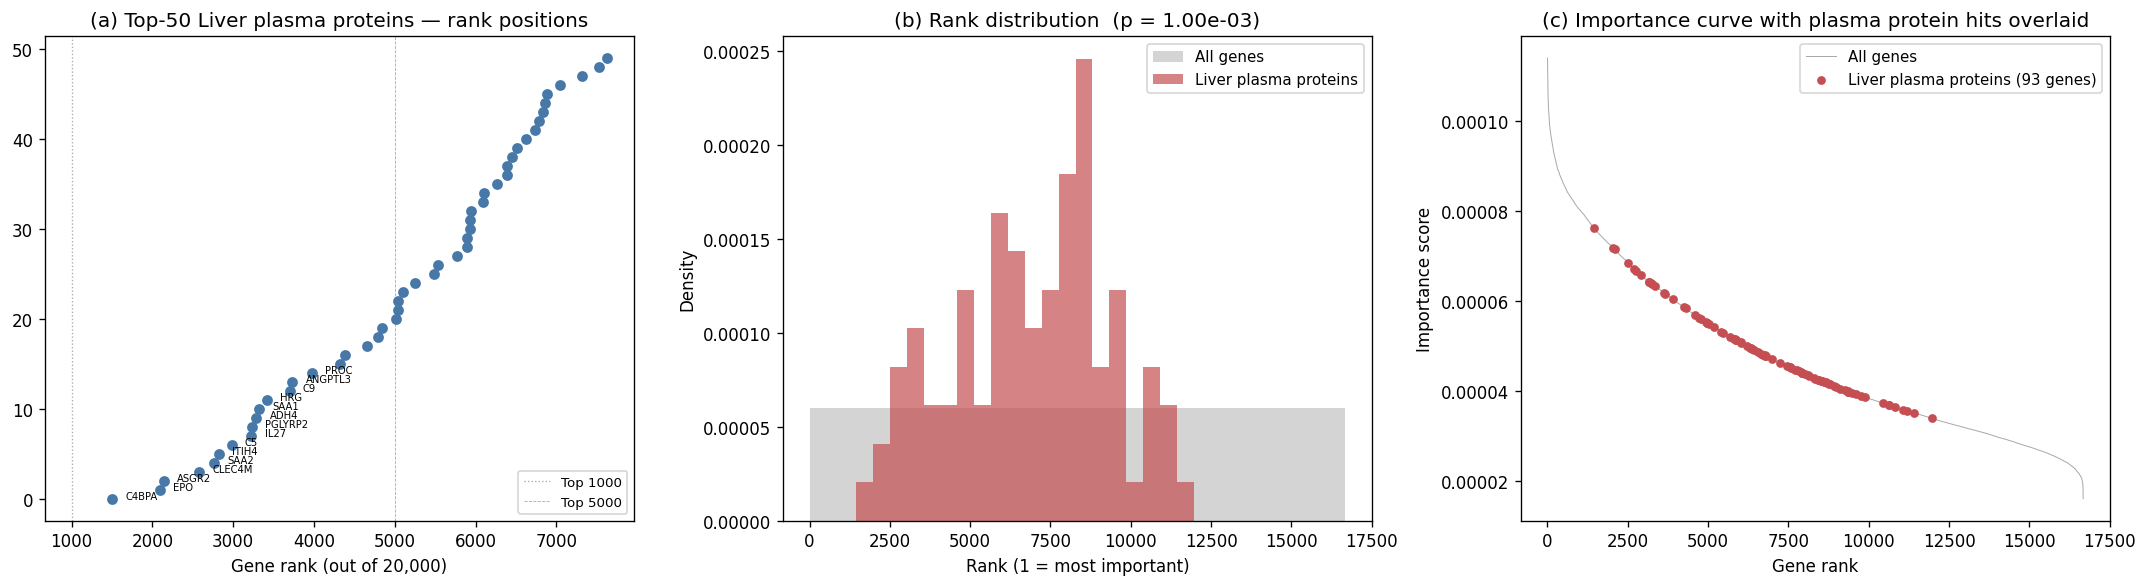

In [3]:
pair = ("Liver", "cirrhosis")
organ = PAIR_ORGAN[pair]
rnk = build_rnk(pair)

# --- (a) GSEA summary + top hits ---
r_plasma = run_gsea(rnk, PLASMA[organ], f"Plasma_{organ}")
gsea_table = pd.DataFrame([r_plasma])[GSEA_COLS]
gsea_table.insert(0, "source", ["Plasma"])
gsea_table.insert(1, "n_genes", [len(PLASMA[organ])])
gsea_table["Lead_genes"] = gsea_table["Lead_genes"].str[:80] + "..."
print(f"Liver | cirrhosis — GSEA prerank vs {len(PLASMA[organ])} Liver plasma proteins:")
display(gsea_table.drop(columns="Term"))

rk = imp[(imp["tissue"]==pair[0]) & (imp["category"]==pair[1])].sort_values("rank")
liver_set = set(PLASMA[organ])
hits = rk[rk["gene_upper"].isin(liver_set)][["rank","gene_name","importance"]]
print(f"\n{len(hits)} Liver plasma protein genes found in the 20K ranking. Top 20:")
display(hits.head(20))

# --- (b,c) visual deep dive: rank positions + rank distribution + importance curve ---
genes_ranked = rnk["gene"].values
imp_ranked = rnk["score"].values
N = len(genes_ranked)
hit_ranks = np.array([i+1 for i, g in enumerate(genes_ranked) if g in liver_set])
hit_imps = np.array([imp_ranked[i] for i, g in enumerate(genes_ranked) if g in liver_set])

fig, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(18, 5))

# (a) Rank positions of the top 50 Liver plasma protein genes
top50 = hits.head(50)
ax0.scatter(top50["rank"], range(len(top50)), c=STEEL, s=30, zorder=3)
for i, (_, r) in enumerate(top50.head(15).iterrows()):
    ax0.annotate(r["gene_name"], (r["rank"], i),
                 fontsize=6, xytext=(8, 0), textcoords="offset points")
ax0.axvline(1000, color=GRAY, ls=":", lw=0.8, label="Top 1000")
ax0.axvline(5000, color=GRAY, ls="--", lw=0.5, label="Top 5000")
ax0.set(xlabel="Gene rank (out of 20,000)",
        title="(a) Top-50 Liver plasma proteins — rank positions")
ax0.legend(fontsize=8)

# (b) Density histogram: hits vs uniform background
ax1.hist(np.arange(1, N+1), bins=20, density=True, color=GRAY, alpha=0.5,
         label="All genes")
ax1.hist(hit_ranks, bins=20, density=True, color=CORAL, alpha=0.7,
         label="Liver plasma proteins")
ax1.set_xlabel("Rank (1 = most important)")
ax1.set_ylabel("Density")
ax1.set_title(f"(b) Rank distribution  (p = {r_plasma['NOM p-val']:.2e})")
ax1.legend(loc="upper right", fontsize=9)

# (c) Importance curve with hits overlaid
ax2.plot(np.arange(1, N+1), imp_ranked, color=GRAY, lw=0.6, label="All genes")
ax2.scatter(hit_ranks, hit_imps, color=CORAL, s=18, zorder=3,
            label=f"Liver plasma proteins ({len(hit_ranks)} genes)")
ax2.set_xlabel("Gene rank")
ax2.set_ylabel("Importance score")
ax2.set_title("(c) Importance curve with plasma protein hits overlaid")
ax2.legend(loc="upper right", fontsize=9)

plt.tight_layout()
fig.savefig(Config.FIGURES_DIR / "plasma_liver_cirrhosis_deepdive.pdf", bbox_inches="tight")
plt.show()

## 13.2 — Scale to All Qualifying Pairs

Run GSEA prerank for every pair in `PAIR_ORGAN` against its organ plasma protein set. Pairs are auto-discovered from `pc_gene_importance_full.csv`, restricted to tissues with a matching organ in Oh et al. ST5.

In [4]:
rows = []
for p in PAIRS:
    organ = PAIR_ORGAN[p]
    rnk = build_rnk(p)
    lbl = label(p)

    if organ not in PLASMA:
        continue
    r = run_gsea(rnk, PLASMA[organ], f"Plasma_{organ}")
    if r is None:
        continue
    rows.append({"pair": lbl, "organ": organ,
                 "n": len(PLASMA[organ]), "ES": r["ES"], "NES": r["NES"],
                 "p": r["NOM p-val"], "FDR": r["FDR q-val"],
                 "Tag %": r["Tag %"], "Gene %": r["Gene %"],
                 "Lead_genes": r["Lead_genes"]})

results_plasma = pd.DataFrame(rows)
display(results_plasma.drop(columns="Lead_genes"))

# Print leading-edge genes for significant results
print("\nLeading-edge genes (p < 0.05):")
for _, r in results_plasma[results_plasma["p"] < 0.05].iterrows():
    genes = r["Lead_genes"].split(";")
    print(f"\n  {r['pair']} ({len(genes)} genes):")
    print(f"    {', '.join(genes[:15])}{'...' if len(genes)>15 else ''}")

,pair,organ,n,ES,NES,p,FDR,Tag %,Gene %
0,Liver | cirrhosis,Liver,105,0.345722,1.749012,0.001000,0.001000,83/93,57.57%
1,Liver | steatosis,Liver,105,0.427176,1.960055,0.001000,0.001000,93/93,57.52%
2,Lung | edema,Lung,9,0.621223,1.614004,0.027708,0.027708,6/7,27.80%
3,Small Intestine - Terminal Ileum | nodularity,Intestine,33,0.588929,1.866436,0.001218,0.001218,9/11,29.43%



Leading-edge genes (p < 0.05):

  Liver | cirrhosis (83 genes):
    C4BPA, EPO, ASGR2, CLEC4M, SAA2, ITIH4, C5, IL27, PGLYRP2, ADH4, SAA1, HRG, C9, ANGPTL3, PROC...

  Liver | steatosis (93 genes):
    C4BPA, HRG, EPO, ADH4, ANGPTL3, CLEC4M, C9, ASGR2, SAA2, ALB, PGLYRP2, ITIH4, SAA1, C5, APOA2...

  Lung | edema (6 genes):
    FCN3, CSF2, SFTPD, CCL18, SFTPB, SFTA2

  Small Intestine - Terminal Ileum | nodularity (9 genes):
    BTNL3, FABP2, DEFA5, ADAMDEC1, CCL25, APOA4, LGALS4, FABP6, REG4


## 13.3 — NES Comparison Across Pairs

Bar chart of GSEA NES across pairs. Coral = p < 0.05.

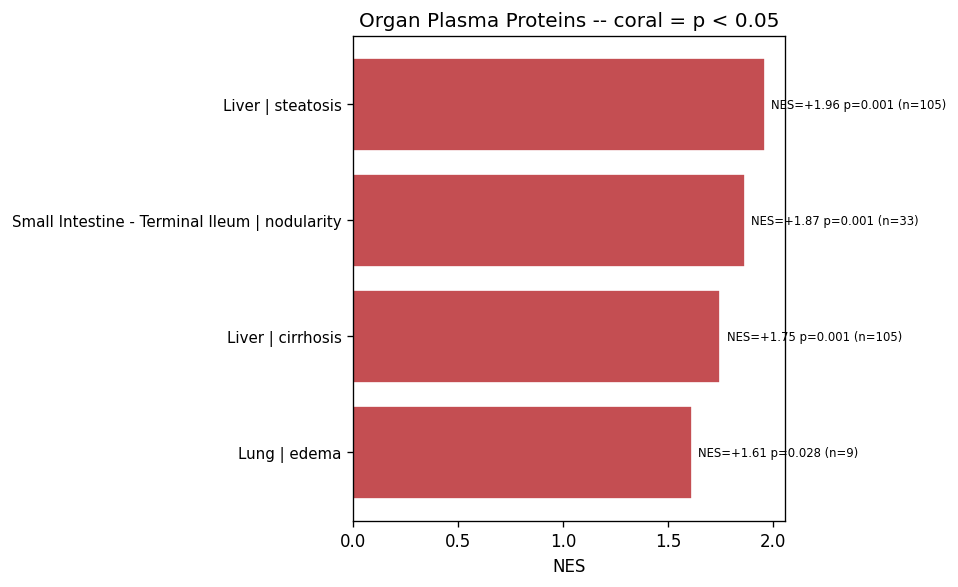

In [5]:
df = results_plasma.sort_values("NES", ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
y = range(len(df))
colors = [CORAL if p < 0.05 else GRAY for p in df["p"]]
ax.barh(y, df["NES"], color=colors, edgecolor="white")
ax.set_yticks(y)
ax.set_yticklabels(df["pair"], fontsize=9)
ax.axvline(0, color="black", lw=0.5)
ax.set(xlabel="NES", title="Organ Plasma Proteins -- coral = p < 0.05")

# Annotate NES, p, n on each bar
for i, (_, r) in enumerate(df.iterrows()):
    p_txt = f"p={r['p']:.3f}" if not np.isnan(r['p']) else ""
    ax.text(max(r["NES"]+0.03, 0.05), i,
            f"NES={r['NES']:+.2f} {p_txt} (n={int(r['n'])})",
            va="center", fontsize=7)

plt.tight_layout()
fig.savefig(Config.FIGURES_DIR / "plasma_nes_bar_all_pairs.pdf", bbox_inches="tight")
plt.show()

## 13.4 — Plasma Protein Leading-Edge Genes Across Pairs

For each significant plasma protein result, collect the leading-edge genes and look up their rank
in **every** pair (including pairs where plasma proteins weren't tested). The heatmap reveals which
organ-specific plasma proteins are consistently prioritised versus those specific to a single pair.

108 leading-edge genes across 4 pairs


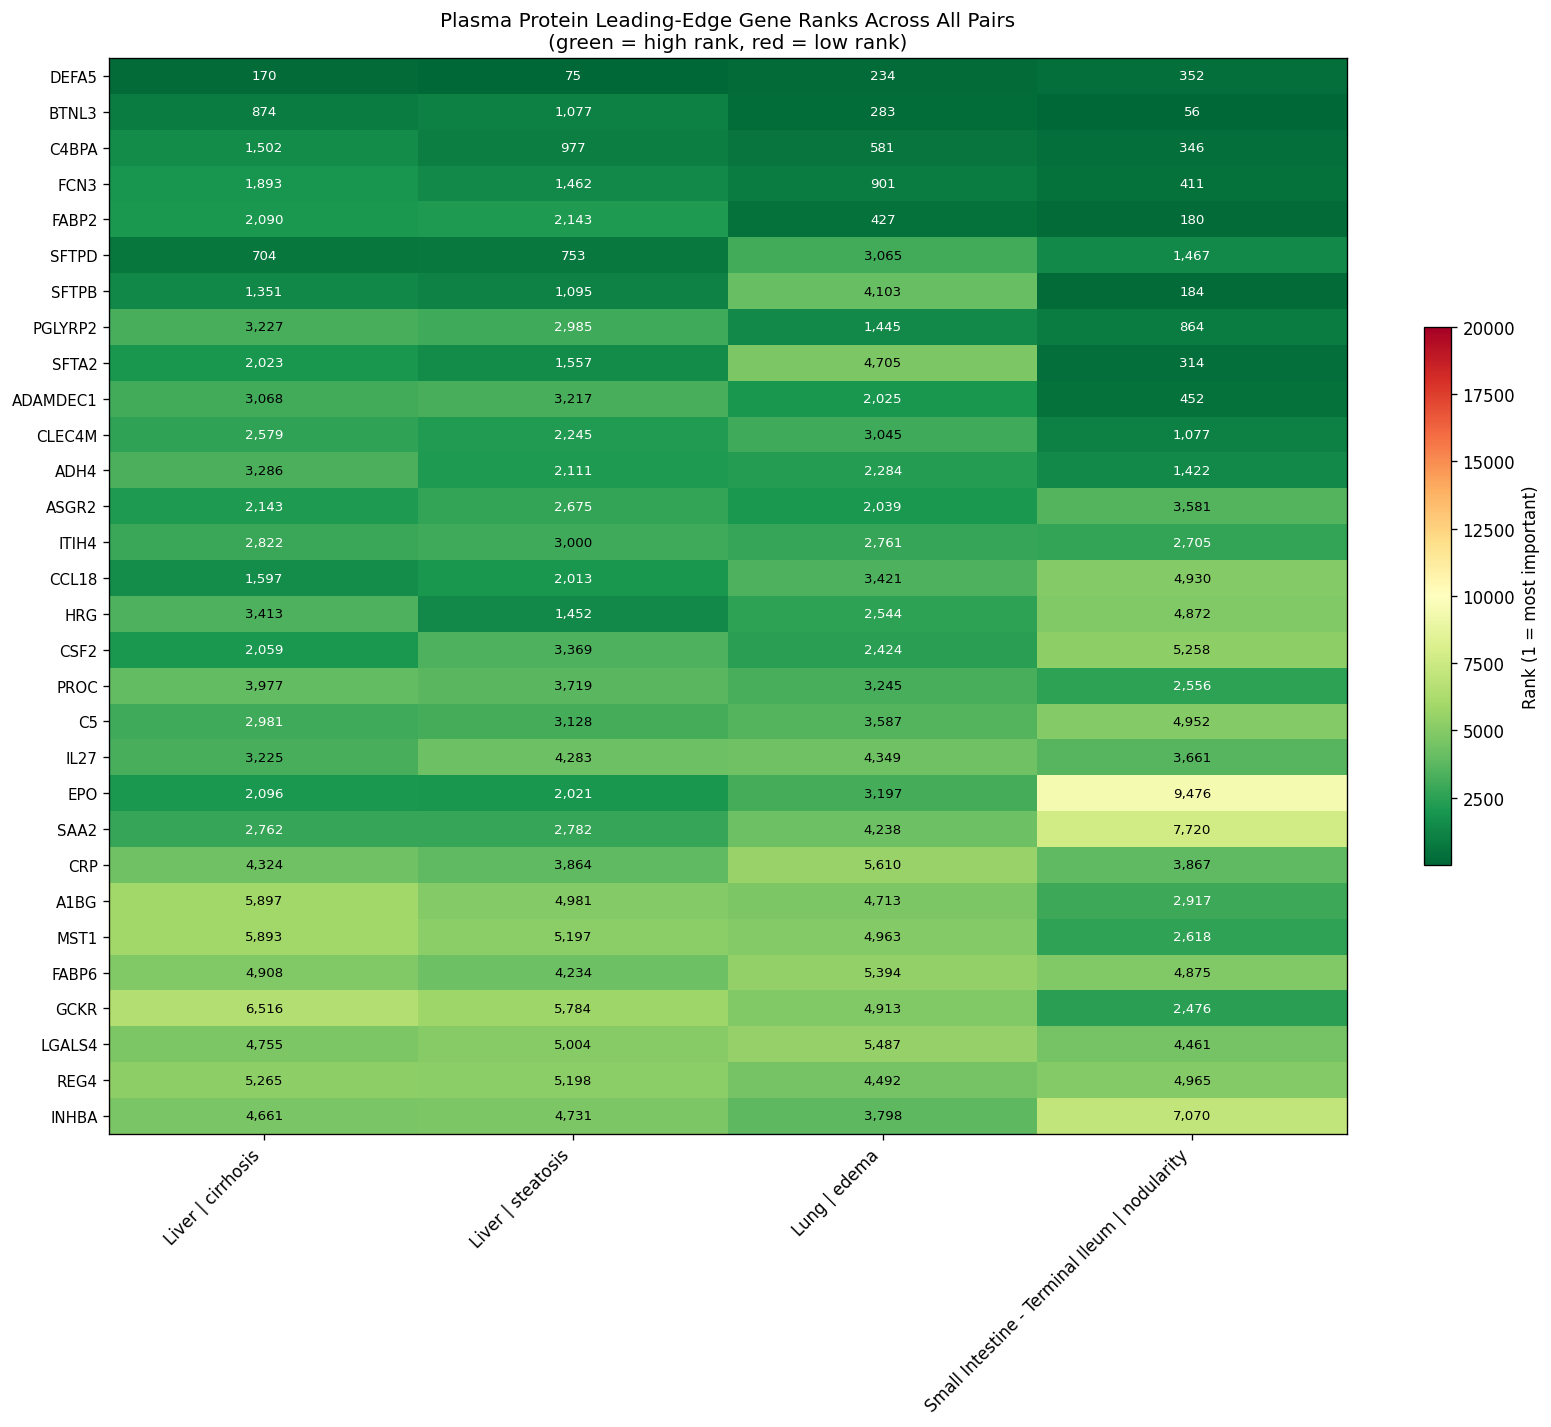


Top leading-edge genes by mean rank across all pairs:
  DEFA5         mean=208  best=75 (Liver | steatosis)
  BTNL3         mean=572  best=56 (Small Intestine - Terminal Ileum | nodularity)
  C4BPA         mean=852  best=346 (Small Intestine - Terminal Ileum | nodularity)
  FCN3          mean=1,167  best=411 (Small Intestine - Terminal Ileum | nodularity)
  FABP2         mean=1,210  best=180 (Small Intestine - Terminal Ileum | nodularity)
  SFTPD         mean=1,497  best=704 (Liver | cirrhosis)
  SFTPB         mean=1,683  best=184 (Small Intestine - Terminal Ileum | nodularity)
  PGLYRP2       mean=2,130  best=864 (Small Intestine - Terminal Ileum | nodularity)
  SFTA2         mean=2,150  best=314 (Small Intestine - Terminal Ileum | nodularity)
  ADAMDEC1      mean=2,190  best=452 (Small Intestine - Terminal Ileum | nodularity)
  CLEC4M        mean=2,236  best=1,077 (Small Intestine - Terminal Ileum | nodularity)
  ADH4          mean=2,276  best=1,422 (Small Intestine - Terminal Ileum

In [6]:
# Collect leading-edge genes from significant plasma protein results
sig = results_plasma[results_plasma["p"] < 0.05]

le_genes = set()
for _, r in sig.iterrows():
    le_genes |= set(r["Lead_genes"].split(";"))

# Build rank matrix: leading-edge genes (rows) x all pairs (columns)
pair_labels = [label(p) for p in PAIRS]
rank_matrix = []
for gene in sorted(le_genes):
    row = {"gene": gene}
    for p in PAIRS:
        rk = imp[(imp["tissue"]==p[0]) & (imp["category"]==p[1])]
        match = rk[rk["gene_upper"] == gene]
        row[label(p)] = int(match["rank"].iloc[0]) if len(match) else np.nan
    rank_matrix.append(row)

rank_df = pd.DataFrame(rank_matrix).set_index("gene")
print(f"{len(rank_df)} leading-edge genes across {len(pair_labels)} pairs")

# Heatmap: top 30 by mean rank
top_le = rank_df.mean(axis=1).nsmallest(30).index
plot_data = rank_df.loc[top_le][pair_labels]

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(plot_data.values, cmap="RdYlGn_r", aspect="auto", vmin=1, vmax=20000)
ax.set_xticks(range(len(pair_labels)))
ax.set_xticklabels(pair_labels, rotation=45, ha="right", fontsize=10)
ax.set_yticks(range(len(top_le)))
ax.set_yticklabels(top_le, fontsize=9)

for i in range(plot_data.shape[0]):
    for j in range(plot_data.shape[1]):
        v = plot_data.values[i, j]
        if np.isnan(v):
            ax.text(j, i, "—", ha="center", va="center", fontsize=8, color="gray")
            continue
        color = "white" if v < 3000 else "black"
        ax.text(j, i, f"{int(v):,}", ha="center", va="center", fontsize=8, color=color)

ax.set_title("Plasma Protein Leading-Edge Gene Ranks Across All Pairs\n(green = high rank, red = low rank)",
             fontsize=12)
plt.colorbar(im, ax=ax, shrink=0.5, label="Rank (1 = most important)")
plt.tight_layout()
fig.savefig(Config.FIGURES_DIR / "plasma_leading_edge_heatmap.pdf", bbox_inches="tight")
plt.show()

# Print top genes by mean rank
print("\nTop leading-edge genes by mean rank across all pairs:")
mean_ranks = rank_df.mean(axis=1).sort_values()
for gene in mean_ranks.head(15).index:
    ranks = rank_df.loc[gene]
    top_pair = ranks.idxmin()
    print(f"  {gene:12s}  mean={ranks.mean():,.0f}  best={int(ranks.min()):,} ({top_pair})")

## 13.5 — Per-Pair Plasma Enrichment Summary

NES of each pair's ranking against its own organ's plasma protein set. This is the
headline measure of how strongly the blood signature recapitulates the organ's
secreted proteome (asterisks = p < 0.05).

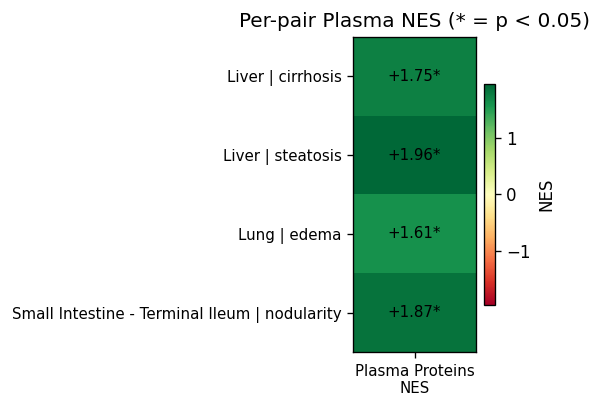

,pair,NES_Plasma,p_Plasma
0,Liver | cirrhosis,1.749012,0.001000
1,Liver | steatosis,1.960055,0.001000
2,Lung | edema,1.614004,0.027708
3,Small Intestine - Terminal Ileum | nodularity,1.866436,0.001218


In [7]:
# Per-pair plasma NES summary (plasma layer only).
pair_order = [label(p) for p in PAIRS]
score = (pd.DataFrame({"pair": pair_order})
         .merge(results_plasma[["pair","NES","p"]]
                .rename(columns={"NES":"NES_Plasma","p":"p_Plasma"}),
                on="pair", how="left"))

data = score[["NES_Plasma"]].values.astype(float)
pvals = score[["p_Plasma"]].values.astype(float)
vmax = max(np.nanmax(np.abs(data)) if np.isfinite(np.nanmax(np.abs(data))) else 2.0, 1.0)

fig, ax = plt.subplots(figsize=(4.5, 0.5 * len(score) + 1.5))
im = ax.imshow(data, cmap="RdYlGn", aspect="auto", vmin=-vmax, vmax=vmax)
ax.set_xticks([0]); ax.set_xticklabels(["Plasma Proteins\nNES"], fontsize=9)
ax.set_yticks(range(len(score))); ax.set_yticklabels(score["pair"], fontsize=9)
for i in range(data.shape[0]):
    v, pv = data[i, 0], pvals[i, 0]
    if np.isnan(v):
        ax.text(0, i, "\u2014", ha="center", va="center", fontsize=10, color="gray")
        continue
    star = "*" if (not np.isnan(pv) and pv < 0.05) else ""
    ax.text(0, i, f"{v:+.2f}{star}", ha="center", va="center", fontsize=9, color="black")
ax.set_title("Per-pair Plasma NES (* = p < 0.05)")
plt.colorbar(im, ax=ax, shrink=0.7, label="NES")
plt.tight_layout()
fig.savefig(Config.FIGURES_DIR / "plasma_nes_summary.pdf", bbox_inches="tight")
plt.show()
score

## 13.6 — Plasma Leading-Edge Flagship Genes

Genes in the **leading edge of the plasma GSEA** for each pair — the subset responsible
for the enrichment signal. These are the most credible organ-secreted biomarker candidates
surfaced by the pipeline for each pathology.

In [8]:
# Flagship genes: leading edge of the plasma GSEA per pair.
def _le_set(df, pair_label):
    row = df[df["pair"] == pair_label]
    if row.empty or pd.isna(row.iloc[0]["Lead_genes"]):
        return set()
    return set(str(row.iloc[0]["Lead_genes"]).split(";"))

rows = []
for p in PAIRS:
    lbl = label(p)
    plasma_le = _le_set(results_plasma, lbl)
    if not plasma_le:
        continue
    rk = imp[(imp["tissue"]==p[0]) & (imp["category"]==p[1])].sort_values("rank")
    for gene in sorted(plasma_le):
        match = rk[rk["gene_upper"] == gene]
        if match.empty:
            continue
        rows.append({"pair": lbl, "gene": gene, "rank": int(match["rank"].iloc[0])})

flagship = (pd.DataFrame(rows).sort_values(["pair","rank"])
            if rows else pd.DataFrame(columns=["pair","gene","rank"]))
print(f"Flagship genes (plasma leading edge): {len(flagship)}")
flagship

Flagship genes (plasma leading edge): 191


,pair,gene,rank
25,Liver | cirrhosis,C4BPA,1502
41,Liver | cirrhosis,EPO,2096
22,Liver | cirrhosis,ASGR2,2143
36,Liver | cirrhosis,CLEC4M,2579
71,Liver | cirrhosis,SAA2,2762
...,...,...,...
185,Small Intestine - Terminal Ileum | nodularity,CCL25,1464
183,Small Intestine - Terminal Ileum | nodularity,APOA4,4421
189,Small Intestine - Terminal Ileum | nodularity,LGALS4,4461
188,Small Intestine - Terminal Ileum | nodularity,FABP6,4875


## 13.7 — Plasma Cross-Organ Specificity

For each qualifying pair, test enrichment against **every** organ's plasma protein set in
Oh et al. ST5, not just its own. Produces a 5 × N NES matrix. The diagonal (own-organ
cells) should be much stronger than the off-diagonal cells; a clean diagonal is the
quantitative evidence that our signatures are **organ-specific** rather than picking up a
generic plasma protein response.

Three outputs:

1. **Jaccard overlap of plasma sets** — baseline: how non-orthogonal are the organ columns?
2. **5 × N NES heatmap** — own-organ cells circled.
3. **Specificity ratio** per pair: `NES_own / NES_other_max`. Ratio > 1.2 = clean own-organ specificity.


In [9]:
# ── 13.7.1: Jaccard overlap baseline of plasma sets ───────────────────────
import itertools

# Keep only organ columns with at least 5 genes (drop "Conventional", "Organismal", tiny ones)
# Exclude Conventional (4.5K genes) and Organismal (3.7K genes) — these are
# the paper's ubiquitous-protein controls, not organ-specific. Including
# them would dominate any GSEA simply because the sets are huge.
EXCLUDE_FROM_CROSS = {"Conventional", "Organismal"}
plasma_organs = sorted([o for o, g in PLASMA.items()
                        if len(g) >= 5 and o not in EXCLUDE_FROM_CROSS])
print(f"Plasma organ sets evaluated (>= 5 genes): {plasma_organs}")
print(f"Set sizes: {[(o, len(PLASMA[o])) for o in plasma_organs]}")

jac_mat = pd.DataFrame(index=plasma_organs, columns=plasma_organs, dtype=float)
for a, b in itertools.product(plasma_organs, repeat=2):
    A, B = set(PLASMA[a]), set(PLASMA[b])
    jac_mat.loc[a, b] = len(A & B) / len(A | B) if (A | B) else 0.0

print("\nPairwise Jaccard of plasma protein sets (off-diagonal):")
off = jac_mat.where(~np.eye(len(plasma_organs), dtype=bool))
print(f"  median Jaccard = {off.values[~np.isnan(off.values)].mean():.3f}")
print(f"  max Jaccard    = {np.nanmax(off.values):.3f}")
print(f"  top overlaps:")
pairs_jac = [(a, b, jac_mat.loc[a,b]) for a, b in itertools.combinations(plasma_organs, 2)]
for a, b, j in sorted(pairs_jac, key=lambda x: -x[2])[:5]:
    print(f"    {a} <-> {b}: {j:.3f}")


Plasma organ sets evaluated (>= 5 genes): ['Adipose', 'Artery', 'Brain', 'Heart', 'Immune', 'Intestine', 'Kidney', 'Liver', 'Lung', 'Muscle', 'Pancreas']
Set sizes: [('Adipose', 5), ('Artery', 12), ('Brain', 186), ('Heart', 8), ('Immune', 157), ('Intestine', 33), ('Kidney', 12), ('Liver', 105), ('Lung', 9), ('Muscle', 19), ('Pancreas', 34)]

Pairwise Jaccard of plasma protein sets (off-diagonal):
  median Jaccard = 0.000
  max Jaccard    = 0.000
  top overlaps:
    Adipose <-> Artery: 0.000
    Adipose <-> Brain: 0.000
    Adipose <-> Heart: 0.000
    Adipose <-> Immune: 0.000
    Adipose <-> Intestine: 0.000


2026-06-11 02:03:16,857 [ERROR] No gene sets passed through filtering condition !!! 
Hint 1: Try to lower min_size or increase max_size !
Hint 2: Check gene symbols are identifiable to your gmt input.
Hint 3: Gene symbols curated in Enrichr web services are all upcases.



2026-06-11 02:03:16,857 [ERROR] The first entry of your gene_sets (gmt) look like this : { Plasma_Adipose: [ADIPOQ, FABP4, ITLN1, LEP, TNMD]}


2026-06-11 02:03:16,859 [ERROR] The first 5 genes look like this : [ TUBB2A, GSTA7P, FAM210CP, TRBV20OR9-2, KRT77 ]


GSEA failed for Plasma_Adipose: No gene sets passed through filtering condition !!! 
Hint 1: Try to lower min_size or increase max_size !
Hint 2: Check gene symbols are identifiable to your gmt input.
Hint 3: Gene symbols curated in Enrichr web services are all upcases.



2026-06-11 02:03:18,317 [ERROR] No gene sets passed through filtering condition !!! 
Hint 1: Try to lower min_size or increase max_size !
Hint 2: Check gene symbols are identifiable to your gmt input.
Hint 3: Gene symbols curated in Enrichr web services are all upcases.



...

2026-06-11 02:03:25,958 [ERROR] No gene sets passed through filtering condition !!! 
Hint 1: Try to lower min_size or increase max_size !
Hint 2: Check gene symbols are identifiable to your gmt input.
Hint 3: Gene symbols curated in Enrichr web services are all upcases.



2026-06-11 02:03:25,959 [ERROR] The first entry of your gene_sets (gmt) look like this : { Plasma_Kidney: [CRYAA, IFNA7, ITGB6, KAAG1, KL, MCCD1, MIOX, PDZK1, PTH1R, REN, TMEM52B, UMOD]}


2026-06-11 02:03:25,961 [ERROR] The first 5 genes look like this : [ NAIPP1, IFI27, CES1P1, MT-TS2, CCR9 ]


GSEA failed for Plasma_Kidney: No gene sets passed through filtering condition !!! 
Hint 1: Try to lower min_size or increase max_size !
Hint 2: Check gene symbols are identifiable to your gmt input.
Hint 3: Gene symbols curated in Enrichr web services are all upcases.



Computed 36 pair x organ-set GSEA tests


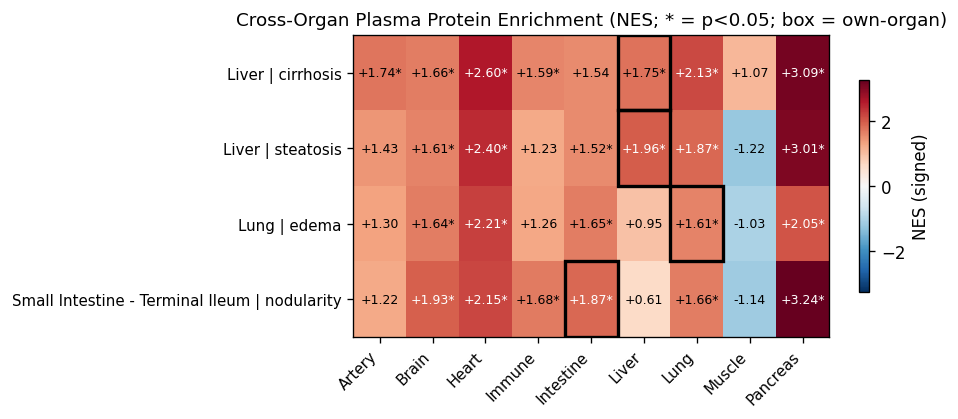

In [10]:
# ── 13.7.2: qualifying-pairs × organs cross-organ GSEA ───────────────────
cross_rows = []
for p in PAIRS:
    lbl = label(p)
    rnk = build_rnk(p)
    own_organ = PAIR_ORGAN[p]
    for organ_set in plasma_organs:
        r = run_gsea(rnk, PLASMA[organ_set], f"Plasma_{organ_set}", min_size=5)
        if r is None:
            continue
        cross_rows.append({
            "pair": lbl, "organ_set": organ_set,
            "n_genes": len(PLASMA[organ_set]),
            "NES": float(r["NES"]) if pd.notna(r["NES"]) else np.nan,
            "p":   float(r["NOM p-val"]) if pd.notna(r["NOM p-val"]) else np.nan,
            "FDR": float(r["FDR q-val"]) if pd.notna(r["FDR q-val"]) else np.nan,
            "is_own": organ_set == own_organ,
        })
cross_plasma = pd.DataFrame(cross_rows)
print(f"Computed {len(cross_plasma)} pair x organ-set GSEA tests")

# Heatmap of signed NES (5 pairs x N organs)
nes_mat = cross_plasma.pivot(index="pair", columns="organ_set", values="NES")
# Reorder rows: keep PAIRS order
nes_mat = nes_mat.reindex([label(p) for p in PAIRS])
sig_mat = cross_plasma.pivot(index="pair", columns="organ_set", values="p") < 0.05
sig_mat = sig_mat.reindex([label(p) for p in PAIRS]).reindex(columns=nes_mat.columns)

vmax = np.nanmax(np.abs(nes_mat.values))
fig, ax = plt.subplots(figsize=(max(8, 0.9 * nes_mat.shape[1]), max(3, 0.9 * nes_mat.shape[0])))
im = ax.imshow(nes_mat.values, cmap="RdBu_r", aspect="auto", vmin=-vmax, vmax=vmax)
ax.set_xticks(range(nes_mat.shape[1]))
ax.set_xticklabels(nes_mat.columns, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(nes_mat.shape[0]))
ax.set_yticklabels(nes_mat.index, fontsize=9)
# Annotate NES values; mark significant cells with *; circle own-organ cells.
for i, pair_lbl in enumerate(nes_mat.index):
    own_organ = PAIR_ORGAN[PAIRS[i]]
    for j, organ_col in enumerate(nes_mat.columns):
        v = nes_mat.iloc[i, j]
        if np.isnan(v):
            continue
        star = "*" if sig_mat.iloc[i, j] else ""
        color = "white" if abs(v) > vmax * 0.55 else "black"
        ax.text(j, i, f"{v:+.2f}{star}", ha="center", va="center", fontsize=7.5, color=color)
        if organ_col == own_organ:
            ax.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1, fill=False, edgecolor="black", lw=2))
ax.set_title("Cross-Organ Plasma Protein Enrichment (NES; * = p<0.05; box = own-organ)", fontsize=11)
plt.colorbar(im, ax=ax, shrink=0.7, label="NES (signed)")
plt.tight_layout()
fig.savefig(Config.FIGURES_DIR / "cross_organ_plasma_nes.pdf", bbox_inches="tight")
plt.show()


In [11]:
# ── 13.7.3: Specificity ratio (NES_own / NES_other_max) ───────────────────
spec_rows = []
for p in PAIRS:
    lbl = label(p)
    sub = cross_plasma[cross_plasma["pair"] == lbl]
    own = sub[sub["is_own"]]
    other = sub[~sub["is_own"]]
    if own.empty:
        continue
    nes_own = float(own["NES"].iloc[0])
    nes_other = other["NES"].astype(float).values
    nes_other_max = float(np.nanmax(nes_other)) if len(nes_other) and np.any(np.isfinite(nes_other)) else np.nan
    nes_other_mean = float(np.nanmean(nes_other)) if len(nes_other) and np.any(np.isfinite(nes_other)) else np.nan
    spec_rows.append({
        "pair": lbl,
        "own_organ": PAIR_ORGAN[p],
        "NES_own": round(nes_own, 3),
        "NES_other_max": round(nes_other_max, 3) if pd.notna(nes_other_max) else np.nan,
        "NES_other_mean": round(nes_other_mean, 3) if pd.notna(nes_other_mean) else np.nan,
        "specificity_ratio": round(nes_own / nes_other_max, 2) if pd.notna(nes_other_max) and nes_other_max > 0 else np.nan,
        "delta_NES_vs_max": round(nes_own - nes_other_max, 3) if pd.notna(nes_other_max) else np.nan,
    })
spec_plasma = pd.DataFrame(spec_rows)
print("Plasma cross-organ specificity per pair:")
display(spec_plasma)

# Headline statistics
print()
print(f"Mean own-organ NES:           {spec_plasma['NES_own'].mean():.3f}")
print(f"Mean best-off-organ NES:      {spec_plasma['NES_other_max'].mean():.3f}")
print(f"Mean specificity ratio:       {spec_plasma['specificity_ratio'].mean():.2f}x")
print(f"Mean delta (NES_own - other): +{spec_plasma['delta_NES_vs_max'].mean():.3f}")

# Save outputs
cross_plasma.to_csv(Config.TABLES_DIR / "cross_organ_plasma_gsea_full.csv", index=False)
spec_plasma.to_csv(Config.TABLES_DIR / "cross_organ_specificity_plasma.csv", index=False)
print("\nSaved: cross_organ_plasma_gsea_full.csv, cross_organ_specificity_plasma.csv")


Plasma cross-organ specificity per pair:


,pair,own_organ,NES_own,NES_other_max,NES_other_mean,specificity_ratio,delta_NES_vs_max
0,Liver | cirrhosis,Liver,1.749,3.087,1.926,0.57,-1.338
1,Liver | steatosis,Liver,1.960,3.009,1.481,0.65,-1.049
2,Lung | edema,Lung,1.614,2.213,1.255,0.73,-0.599
3,Small Intestine - Terminal Ileum | nodularity,Intestine,1.866,3.236,1.419,0.58,-1.370



Mean own-organ NES:           1.797
Mean best-off-organ NES:      2.886
Mean specificity ratio:       0.63x
Mean delta (NES_own - other): +-1.089

Saved: cross_organ_plasma_gsea_full.csv, cross_organ_specificity_plasma.csv


## 13.8 — Export

Save all per-pair GSEA results, the leading-edge rank matrix, the integrated scorecard, and the
flagship gene list for downstream inspection.

In [12]:
results_plasma.to_csv(Config.TABLES_DIR / "organ_enrichment_plasma_gsea.csv", index=False)
rank_df.to_csv(Config.TABLES_DIR / "organ_leading_edge_ranks.csv")
score.to_csv(Config.TABLES_DIR / "plasma_nes_summary.csv", index=False)
flagship.to_csv(Config.TABLES_DIR / "validation_flagship_genes.csv", index=False)

print("Saved:")
print(f"  organ_enrichment_plasma_gsea.csv    ({len(results_plasma)} rows)")
print(f"  organ_leading_edge_ranks.csv        ({len(rank_df)} genes x {rank_df.shape[1]} pairs)")
print(f"  plasma_nes_summary.csv              ({len(score)} rows)")
print(f"  validation_flagship_genes.csv       ({len(flagship)} rows)")

print("\nSignificant plasma enrichments (p < 0.05):")
sig = results_plasma.dropna(subset=["p"])
sig = sig[sig["p"] < 0.05]
print(f"  {len(sig)}/{len(results_plasma)} tests")
for _, r in sig.sort_values("NES", ascending=False).iterrows():
    pair_str = r["pair"]
    nes = r["NES"]
    pv = r["p"]
    print(f"    {pair_str:50s} NES={nes:+.2f} p={pv:.4f}")

Saved:
  organ_enrichment_plasma_gsea.csv    (4 rows)
  organ_leading_edge_ranks.csv        (108 genes x 4 pairs)
  plasma_nes_summary.csv              (4 rows)
  validation_flagship_genes.csv       (191 rows)

Significant plasma enrichments (p < 0.05):
  4/4 tests
    Liver | steatosis                                  NES=+1.96 p=0.0010
    Small Intestine - Terminal Ileum | nodularity      NES=+1.87 p=0.0012
    Liver | cirrhosis                                  NES=+1.75 p=0.0010
    Lung | edema                                       NES=+1.61 p=0.0277
